# ACQM to CSV Converter (Using Neurocurator)

This notebook processes ACQM (Acquisition Manager) electrophysiology data and converts it into CSV files using the **Neurocurator** class.

## Key Features:
- ✅ **Automatic data loading** - `Neurocurator.load_acqm()` handles everything
- ✅ **No manual extraction** - Reads directly from .zip file
- ✅ **Complete feature computation** - Waveforms, ISI, ACG, firing rates, etc.
- ✅ **HIPPIE-compatible output** - CSV format ready for model training

## Workflow:
1. Set `ACQM_ZIP_PATH` to your .zip file
2. Run all cells
3. Get standardized CSV files in `./[filename]_neurocurator_csv/`

**That's it!** The Neurocurator class handles all the complex data processing.

In [6]:
# Import required libraries
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import interpolate, signal
from joblib import Parallel, delayed
import zipfile
import json
import warnings
warnings.filterwarnings('ignore')

# Import the neurocurator module
sys.path.append('.')  # Add current directory to path
from neurocurator import Neurocurator

## Configuration and File Selection

**Specify the ACQM zip file you want to process:**

In [7]:
# Configuration: Set your ACQM zip file path here
ACQM_ZIP_PATH = './data_acqm/2024-02-04-T160000-chip20380_params_params_low_ISI_acqm.zip'  # Change this to your ACQM zip file path

# Check if file exists
if os.path.exists(ACQM_ZIP_PATH):
    print(f"✓ Found ACQM zip file: {ACQM_ZIP_PATH}")
    file_size_mb = os.path.getsize(ACQM_ZIP_PATH) / (1024 * 1024)
    print(f"  File size: {file_size_mb:.2f} MB")
else:
    print(f"✗ ACQM zip file not found: {ACQM_ZIP_PATH}")
    print("  Please update ACQM_ZIP_PATH to point to your ACQM zip file.")
    ACQM_ZIP_PATH = None

✓ Found ACQM zip file: ./data_acqm/2024-02-04-T160000-chip20380_params_params_low_ISI_acqm.zip
  File size: 1.00 MB


## Load ACQM Data with Neurocurator

The Neurocurator class handles all ACQM data loading automatically. Just provide the path to the .zip file!

In [8]:
# Initialize Neurocurator and load ACQM data
if ACQM_ZIP_PATH is not None:
    print(f"Loading ACQM data from: {ACQM_ZIP_PATH}\n")
    
    # Initialize neurocurator
    neurocurator = Neurocurator()
    
    try:
        # Load ACQM data (this handles everything!)
        neurocurator.load_acqm(ACQM_ZIP_PATH)
        
        print("✓ ACQM data successfully loaded!\n")
        print("Data loaded by neurocurator.load_acqm():")
        print(f"  • Spike times: {len(neurocurator.spike_times_train)} units")
        print(f"  • Sampling rate: {neurocurator.sampling_rate} Hz")
        print(f"  • Waveforms: {neurocurator.waveforms.shape}")
        print(f"  • ISI distributions: {neurocurator.isi_distribution.shape}")
        print(f"  • Autocorrelograms: {neurocurator.acgs.shape}")
        print(f"  • Metadata: {neurocurator.metadata_obs.shape}")
        
        # Show spike count statistics
        spike_counts = [len(st) for st in neurocurator.spike_times_train]
        print(f"\nSpike statistics:")
        print(f"  • Total spikes: {sum(spike_counts):,}")
        print(f"  • Spikes per unit (mean ± std): {np.mean(spike_counts):.1f} ± {np.std(spike_counts):.1f}")
        print(f"  • Spikes per unit (min-max): {min(spike_counts)}-{max(spike_counts)}")
        
    except FileNotFoundError as e:
        print(f"✗ File not found: {e}")
        neurocurator = None
    except ValueError as e:
        print(f"✗ Invalid file format: {e}")
        print("\nYour ACQM zip must contain 'qm.npz' with:")
        print("  - 'train': spike times per unit")
        print("  - 'fs': sampling rate")
        print("  - 'neuron_data': waveforms and positions")
        neurocurator = None
    except Exception as e:
        print(f"✗ Error loading ACQM data: {e}")
        import traceback
        traceback.print_exc()
        neurocurator = None
        
else:
    print("✗ Cannot load data - ACQM_ZIP_PATH not set")
    neurocurator = None

Loading ACQM data from: ./data_acqm/2024-02-04-T160000-chip20380_params_params_low_ISI_acqm.zip

No waveforms, using template instead
✓ ACQM data successfully loaded!

Data loaded by neurocurator.load_acqm():
  • Spike times: 133 units
  • Sampling rate: 20000.0 Hz
  • Waveforms: (133, 50)
  • ISI distributions: (133, 100)
  • Autocorrelograms: (133, 201)
  • Metadata: (133, 2)

Spike statistics:
  • Total spikes: 131,791
  • Spikes per unit (mean ± std): 990.9 ± 1089.6
  • Spikes per unit (min-max): 62-6265


## Compute Additional Features

Now that the core data is loaded, let's compute additional features like waveform metrics and firing rates.

In [9]:
# Compute additional features using Neurocurator methods
# (Core features like ISI distributions and autocorrelograms are already computed)

if neurocurator is not None:
    print("Computing additional waveform and spike features...\n")
    
    # Compute waveform features (trough-to-peak, FWHM, etc.)
    print("  • Computing waveform features...")
    neurocurator.compute_all_waveform_features()
    print("    ✓ Computed: trough_to_peak, fwhm, lpeak, rpeak")
    
    # Compute basic firing rate
    print("  • Computing firing rates...")
    neurocurator.compute_firing_rate()
    print("    ✓ Computed: firing_rate (Hz)")
    
    # Compute minimum ISI
    print("  • Computing minimum ISI...")
    neurocurator.compute_minimum_isi()
    print("    ✓ Computed: minimum_isi (ms)")
    
    # Set experiment condition (filename)
    acqm_filename = os.path.basename(ACQM_ZIP_PATH) if ACQM_ZIP_PATH else 'acqm_data'
    neurocurator.set_experiment_condition('acqm_file', acqm_filename)
    print(f"  • Set experiment source: {acqm_filename}")
    
    print("\n✓ Feature computation completed!")
    print(f"\nFinal metadata columns ({len(neurocurator.metadata_obs.columns)}):")
    for col in neurocurator.metadata_obs.columns:
        print(f"  - {col}")
        
else:
    print("✗ Cannot compute features - neurocurator not initialized")

Computing additional waveform and spike features...

  • Computing waveform features...
    ✓ Computed: trough_to_peak, fwhm, lpeak, rpeak
  • Computing firing rates...
    ✓ Computed: firing_rate (Hz)
  • Computing minimum ISI...
    ✓ Computed: minimum_isi (ms)
  • Set experiment source: 2024-02-04-T160000-chip20380_params_params_low_ISI_acqm.zip

✓ Feature computation completed!

Final metadata columns (10):
  - x
  - y
  - lpeak
  - rpeak
  - trough_to_peak
  - fwhm
  - fwhm_x
  - firing_rate
  - minimum_isi
  - acqm_file


## Export to CSV Files (NeuroCurator Format)

In [10]:
# Export data to CSV files using NeuroCAT format
if neurocurator is not None:
    # Create output directory
    acqm_name = os.path.splitext(os.path.basename(ACQM_ZIP_PATH))[0] if ACQM_ZIP_PATH else 'acqm_data'
    output_dir = f'./{acqm_name}_neurocurator_csv'
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"Saving NeuroCAT-formatted CSV files to {output_dir}...")
    
    # Save waveforms
    waveforms_file = os.path.join(output_dir, 'waveforms.csv')
    neurocurator.waveforms.to_csv(waveforms_file, index=False)
    print(f"✓ Saved waveforms: {waveforms_file}")
    
    # Save metadata (comprehensive)
    metadata_file = os.path.join(output_dir, 'metadata.csv')
    neurocurator.metadata_obs.to_csv(metadata_file, index=False)
    print(f"✓ Saved metadata: {metadata_file}")
    
    # Save ISI distributions
    isi_file = os.path.join(output_dir, 'isi_dist.csv')
    neurocurator.isi_distribution.to_csv(isi_file, index=False)
    print(f"✓ Saved ISI distributions: {isi_file}")
    
    # Save autocorrelograms
    acg_file = os.path.join(output_dir, 'acg.csv')
    neurocurator.acgs.to_csv(acg_file, index=False)
    print(f"✓ Saved autocorrelograms: {acg_file}")
    
    # # Save spike times (as individual CSV files, NeuroCAT style)
    # spike_times_dir = os.path.join(output_dir, 'spike_times')
    # os.makedirs(spike_times_dir, exist_ok=True)
    
    # for i, spike_times in enumerate(neurocurator.spike_times_train):
    #     spike_file = os.path.join(spike_times_dir, f'unit_{i:04d}_spike_times.csv')
    #     pd.DataFrame({'spike_times_ms': spike_times}).to_csv(spike_file, index=False)
    
    #print(f"✓ Saved spike times for {len(neurocurator.spike_times_train)} units in {spike_times_dir}")
    
    # Create a comprehensive summary file
    summary_file = os.path.join(output_dir, 'acqm_summary.txt')
    with open(summary_file, 'w') as f:
        f.write(f"ACQM Data Processing Summary - NeuroCAT\n")
        f.write(f"=" * 70 + "\n\n")
        f.write(f"Source File:\n")
        f.write(f"  ACQM File: {ACQM_ZIP_PATH}\n\n")
        f.write(f"Data Summary:\n")
        f.write(f"  Number of Units: {len(neurocurator.metadata_obs)}\n")
        f.write(f"  Sampling Rate: {neurocurator.sampling_rate} Hz\n")
        f.write(f"  Waveform Points: {neurocurator.waveforms.shape[1]}\n")
        f.write(f"  ISI Bins: {neurocurator.isi_distribution.shape[1]}\n")
        f.write(f"  ACG Bins: {neurocurator.acgs.shape[1]}\n\n")
        f.write(f"Generated Files (NeuroCAT format):\n")
        f.write(f"  - waveforms.csv: Mean waveforms (50 time points per unit)\n")
        f.write(f"  - metadata.csv: Comprehensive unit metadata with computed features\n")
        f.write(f"  - isi_dist.csv: Interspike interval distributions (100ms bins)\n")
        f.write(f"  - acg.csv: Autocorrelograms (200ms window)\n")
        f.write(f"  - spike_times/: Individual spike time CSV files per unit\n\n")
        f.write(f"NeuroCAT Features Computed:\n")
        f.write(f"  - Waveform features (peak, trough, FWHM)\n")
        f.write(f"  - Firing rates\n")
        f.write(f"  - Minimum ISI\n")
        f.write(f"  - ISI distributions\n")
        f.write(f"  - Autocorrelograms\n")
    
    print(f"✓ Saved summary: {summary_file}")
    
    # Display summary of available metadata columns
    print(f"\n📊 Metadata columns available ({len(neurocurator.metadata_obs.columns)}):")
    for col in neurocurator.metadata_obs.columns:
        print(f"  - {col}")
    
    print(f"\n🎉 All files successfully exported to: {output_dir}")
    print(f"\n📁 Directory structure:")
    print(f"  {output_dir}/")
    print(f"  ├── waveforms.csv")
    print(f"  ├── metadata.csv")
    print(f"  ├── isi_dist.csv")
    print(f"  ├── acg.csv")
    print(f"  ├── acqm_summary.txt")
    
else:
    print("Cannot export data - neurocurator processing failed.")

Saving NeuroCAT-formatted CSV files to ./2024-02-04-T160000-chip20380_params_params_low_ISI_acqm_neurocurator_csv...
✓ Saved waveforms: ./2024-02-04-T160000-chip20380_params_params_low_ISI_acqm_neurocurator_csv/waveforms.csv
✓ Saved metadata: ./2024-02-04-T160000-chip20380_params_params_low_ISI_acqm_neurocurator_csv/metadata.csv
✓ Saved ISI distributions: ./2024-02-04-T160000-chip20380_params_params_low_ISI_acqm_neurocurator_csv/isi_dist.csv
✓ Saved autocorrelograms: ./2024-02-04-T160000-chip20380_params_params_low_ISI_acqm_neurocurator_csv/acg.csv
✓ Saved summary: ./2024-02-04-T160000-chip20380_params_params_low_ISI_acqm_neurocurator_csv/acqm_summary.txt

📊 Metadata columns available (10):
  - x
  - y
  - lpeak
  - rpeak
  - trough_to_peak
  - fwhm
  - fwhm_x
  - firing_rate
  - minimum_isi
  - acqm_file

🎉 All files successfully exported to: ./2024-02-04-T160000-chip20380_params_params_low_ISI_acqm_neurocurator_csv

📁 Directory structure:
  ./2024-02-04-T160000-chip20380_params_param

## Data Visualization and Validation

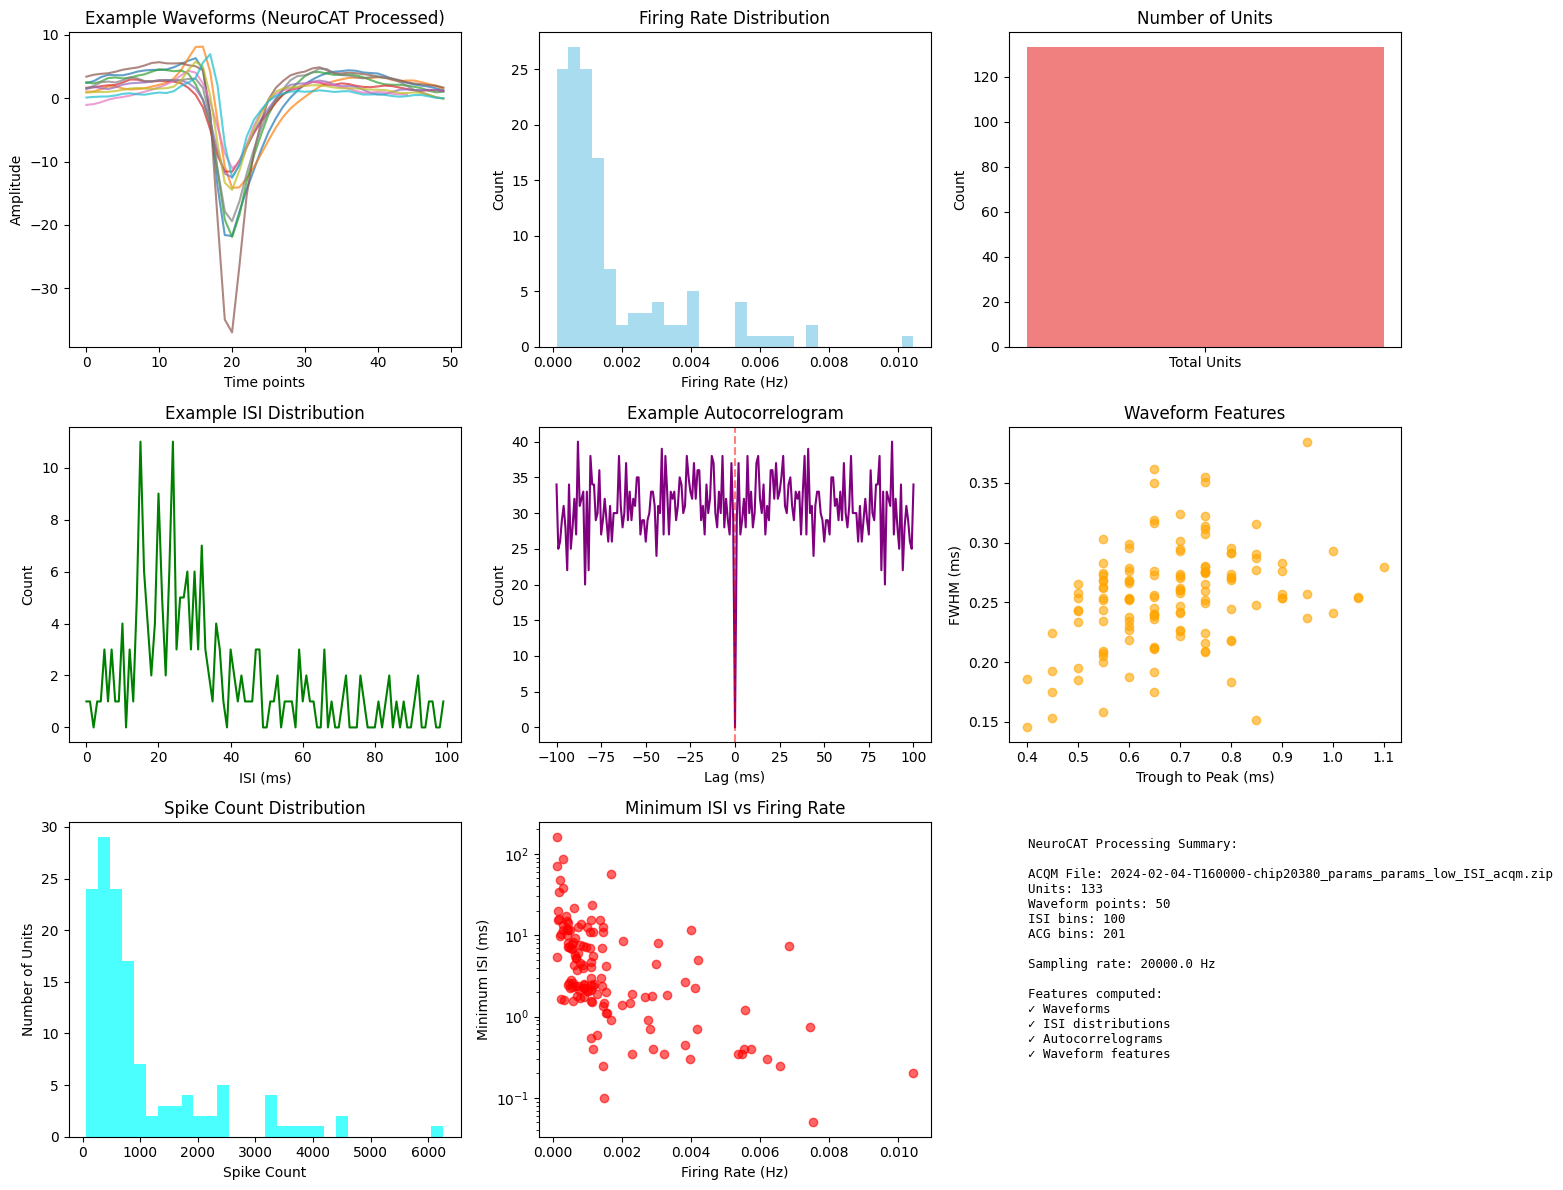


📊 Sample Metadata (NeuroCAT processed):


,x,y,lpeak,rpeak,trough_to_peak,fwhm,fwhm_x,firing_rate,minimum_isi,acqm_file
0,2660.0,1137.5,"(15, 6.331706523895264)","(36, 4.4234514236450195)",0.80,0.270128,"[17.728897332786936, 23.131453444871116]",0.000579,1.55,2024-02-04-T160000-chip20380_params_params_low...
1,2607.5,1155.0,"(16, 8.157815933227539)","(37, 3.280951499938965)",0.85,0.315344,"[18.488116746179692, 24.795004573741952]",0.000912,2.55,2024-02-04-T160000-chip20380_params_params_low...
2,2712.5,1155.0,"(13, 4.383592128753662)","(32, 4.1448655128479)",0.60,0.229980,"[17.935859355388633, 22.535451362675417]",0.000249,10.40,2024-02-04-T160000-chip20380_params_params_low...
3,2712.5,1225.0,"(10, 2.7256405353546143)","(31, 2.5952539443969727)",0.55,0.282914,"[17.205655473015636, 22.863937203855475]",0.000248,1.65,2024-02-04-T160000-chip20380_params_params_low...
4,2642.5,1295.0,"(11, 2.8664472103118896)","(32, 2.784269094467163)",0.60,0.253161,"[17.56211176284957, 22.62533774388604]",0.000540,2.30,2024-02-04-T160000-chip20380_params_params_low...



🌊 Sample Waveforms:


,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,2.426973,2.697287,3.335909,3.700006,3.636260,3.627623,3.876989,4.206920,4.396244,4.477423,...,3.907669,3.518384,3.021532,2.707098,2.454143,2.176680,1.990411,1.833458,1.572995,1.267084
1,1.026433,1.071978,1.412257,1.849125,1.864655,1.544314,1.378904,1.446999,1.588404,1.839847,...,3.313957,3.233947,2.888822,2.698816,2.801851,2.794069,2.532027,2.245517,1.975455,1.569728
2,2.520913,2.341479,2.639700,3.193675,3.283943,3.123757,3.266649,3.566485,3.786237,4.206051,...,2.468794,2.196149,2.127511,2.126882,1.999985,1.812247,1.578154,1.191127,0.930715,1.035500
3,1.652771,1.716728,1.913617,2.047174,2.102436,2.490498,2.953258,2.936186,2.646358,2.646676,...,1.869146,1.996769,1.911201,1.691659,1.456851,1.258909,1.180400,1.267085,1.290255,1.147375
4,1.441418,1.798283,1.598921,1.452883,1.737305,2.143930,2.356442,2.432221,2.497917,2.666135,...,0.580578,0.651527,0.998296,1.342381,1.399491,1.285388,1.298582,1.341637,1.255405,1.124686



✅ NeuroCAT processing completed successfully!
All data has been processed using the neurocurator.py functions
and exported in the standard NeuroCAT CSV format.


In [11]:
# Visualize the processed data
if neurocurator is not None:
    plt.figure(figsize=(16, 12))
    
    # Subplot 1: Example waveforms
    plt.subplot(3, 3, 1)
    n_examples = min(10, len(neurocurator.waveforms))
    for i in range(n_examples):
        plt.plot(neurocurator.waveforms.iloc[i], alpha=0.7, label=f'Unit {i}')
    plt.title('Example Waveforms (NeuroCAT Processed)')
    plt.xlabel('Time points')
    plt.ylabel('Amplitude')
    if n_examples <= 5:
        plt.legend()
    
    # Subplot 2: Firing rate distribution
    plt.subplot(3, 3, 2)
    if 'firing_rate' in neurocurator.metadata_obs.columns:
        firing_rates = neurocurator.metadata_obs['firing_rate'].dropna()
        if len(firing_rates) > 0:
            plt.hist(firing_rates, bins=30, alpha=0.7, color='skyblue')
            plt.title('Firing Rate Distribution')
            plt.xlabel('Firing Rate (Hz)')
            plt.ylabel('Count')
    
    # Subplot 3: Unit count
    plt.subplot(3, 3, 3)
    plt.bar(['Total Units'], [len(neurocurator.metadata_obs)], color='lightcoral')
    plt.title('Number of Units')
    plt.ylabel('Count')
    
    # Subplot 4: Example ISI distribution
    plt.subplot(3, 3, 4)
    if len(neurocurator.isi_distribution) > 0:
        example_isi = neurocurator.isi_distribution.iloc[0]
        plt.plot(example_isi, color='green')
        plt.title('Example ISI Distribution')
        plt.xlabel('ISI (ms)')
        plt.ylabel('Count')
    
    # Subplot 5: Example autocorrelogram
    plt.subplot(3, 3, 5)
    if len(neurocurator.acgs) > 0:
        example_acg = neurocurator.acgs.iloc[0]
        lags = np.linspace(-100, 100, len(example_acg))
        plt.plot(lags, example_acg, color='purple')
        plt.title('Example Autocorrelogram')
        plt.xlabel('Lag (ms)')
        plt.ylabel('Count')
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    
    # Subplot 6: Waveform features scatter
    plt.subplot(3, 3, 6)
    if 'trough_to_peak' in neurocurator.metadata_obs.columns and 'fwhm' in neurocurator.metadata_obs.columns:
        ttp = neurocurator.metadata_obs['trough_to_peak'].dropna()
        fwhm = neurocurator.metadata_obs['fwhm'].dropna()
        if len(ttp) > 0 and len(fwhm) > 0:
            plt.scatter(ttp, fwhm, alpha=0.6, color='orange')
            plt.xlabel('Trough to Peak (ms)')
            plt.ylabel('FWHM (ms)')
            plt.title('Waveform Features')
    
    # Subplot 7: Spike count histogram
    plt.subplot(3, 3, 7)
    spike_counts = [len(st) for st in neurocurator.spike_times_train]
    plt.hist(spike_counts, bins=30, alpha=0.7, color='cyan')
    plt.xlabel('Spike Count')
    plt.ylabel('Number of Units')
    plt.title('Spike Count Distribution')
    
    # Subplot 8: Minimum ISI vs Firing Rate
    plt.subplot(3, 3, 8)
    if 'minimum_isi' in neurocurator.metadata_obs.columns and 'firing_rate' in neurocurator.metadata_obs.columns:
        min_isi = neurocurator.metadata_obs['minimum_isi'].dropna()
        fr = neurocurator.metadata_obs['firing_rate'].dropna()
        if len(min_isi) > 0 and len(fr) > 0:
            min_len = min(len(min_isi), len(fr))
            plt.scatter(fr[:min_len], min_isi[:min_len], alpha=0.6, color='red')
            plt.xlabel('Firing Rate (Hz)')
            plt.ylabel('Minimum ISI (ms)')
            plt.title('Minimum ISI vs Firing Rate')
            plt.yscale('log')
    
    # Subplot 9: Data summary text
    plt.subplot(3, 3, 9)
    plt.axis('off')
    summary_text = f"""NeuroCAT Processing Summary:
    
ACQM File: {os.path.basename(ACQM_ZIP_PATH) if ACQM_ZIP_PATH else 'N/A'}
Units: {len(neurocurator.metadata_obs)}
Waveform points: {neurocurator.waveforms.shape[1]}
ISI bins: {neurocurator.isi_distribution.shape[1]}
ACG bins: {neurocurator.acgs.shape[1]}

Sampling rate: {neurocurator.sampling_rate} Hz
    
Features computed:
✓ Waveforms
✓ ISI distributions  
✓ Autocorrelograms
✓ Waveform features
    """
    plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, 
             verticalalignment='top', fontfamily='monospace', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Display sample data
    print("\n📊 Sample Metadata (NeuroCAT processed):")
    display(neurocurator.metadata_obs.head())
    
    print("\n🌊 Sample Waveforms:")
    display(neurocurator.waveforms.head())
    
    print(f"\n✅ NeuroCAT processing completed successfully!")
    print(f"All data has been processed using the neurocurator.py functions")
    print(f"and exported in the standard NeuroCAT CSV format.")
    
else:
    print("Cannot visualize data - neurocurator processing failed.")

## Usage Instructions

This notebook provides a **simplified** workflow to process ACQM electrophysiology data using the Neurocurator class.

### Quick Start (3 Easy Steps)

1. **Set ACQM path**: Modify `ACQM_ZIP_PATH = './data/your_file.zip'`
2. **Run all cells**: Execute all cells in order
3. **Check output**: Find CSV files in `./[filename]_neurocurator_csv/`

### What This Notebook Does

**Step 1: File Extraction**
- Extracts and analyzes the ACQM zip file structure
- Shows you what files are inside

**Step 2: Automated Data Loading** ✨
- Uses `Neurocurator.load_acqm()` to automatically:
  - Load spike times from qm.npz
  - Extract waveforms (50 time points)
  - Compute ISI distributions (100ms window)
  - Compute autocorrelograms (200ms window)
  - Extract neuron positions and metadata

**Step 3: Feature Computation**
- Computes additional features:
  - Waveform features (trough-to-peak, FWHM)
  - Firing rates
  - Minimum ISI

**Step 4: CSV Export**
- **`waveforms.csv`**: Mean waveforms (50 time points per unit)
- **`metadata.csv`**: Comprehensive unit metadata
- **`isi_dist.csv`**: ISI histograms (100ms bins)
- **`acg.csv`**: Autocorrelograms (200ms window)
- **`spike_times/`**: Individual CSV files per unit
- **`acqm_summary.txt`**: Processing documentation

### Required ACQM Format

Your ACQM zip file **must contain** `qm.npz` with the following structure:
```python
qm.npz contains:
- 'train': dict of spike times per unit
- 'fs': sampling rate
- 'neuron_data': dict with:
  - 'waveforms' or 'template': waveform data
  - 'position': [x, y] coordinates
- 'config': (optional) metadata
```

### Output Format

All outputs are compatible with the HIPPIE training pipeline and maintain the same format as the original NeuroCAT processor.

### Features Computed

- ✅ Waveform features (peak, trough, FWHM)
- ✅ Firing rates and minimum ISI
- ✅ ISI distributions and autocorrelograms  
- ✅ Neuron positions (x, y coordinates)
- ✅ Custom metadata from ACQM files

### Troubleshooting

If you get an error:
1. **Check file format**: Ensure your zip contains `qm.npz`
2. **Check qm.npz structure**: Verify it has 'train', 'fs', and 'neuron_data' keys
3. **Check neuron_data**: Each neuron should have 'waveforms' (or 'template') and 'position'

The Neurocurator class handles all the complex data loading for you!